# 06 – Time Series Splitting

Dieses Notebook dokumentiert und überprüft die sechste Stufe des
Bitcoin-Price-Prediction-Projekts.

Voraussetzungen:

- `05_dataset_builder.ipynb` beziehungsweise `dataset_builder.py`
  haben den aufgabenspezifischen Modellierungsdatensatz erzeugt.
- `time_series_splitter.py` hat Holdout-Splits und Walk-Forward-Folds
  geschrieben.
- Die Splitdateien enthalten unveränderte Features, genau ein Target
  und die zugehörige Target-Endzeit.

Untersucht werden:

- chronologische Holdout-Splits,
- expanding- oder rolling-window Cross-Validation,
- Purging an jeder Splitgrenze,
- Embargo nach jeder Grenze,
- Schlüsselüberschneidungen,
- exakte Target-Endzeiten,
- Schemaidentität,
- Klassen- beziehungsweise Targetverteilungen,
- Ausschluss des reservierten Validation- und Testzeitraums aus der
  Cross-Validation,
- deterministische Splitdefinitionen,
- ein abschließendes Leakage-Freigabegate.

Das Notebook trainiert **keine Modelle**. Der Testsplit bleibt für die
Modellauswahl reserviert. Seine Targetverteilung wird standardmäßig
nicht visualisiert.

## 1. Umgebung und Imports

Die Projektwurzel wird automatisch gesucht. Das Notebook kann im
Projektordner oder in einem Unterordner wie `notebooks/` liegen.

In [1]:
from __future__ import annotations

import hashlib
import json
import sys
from pathlib import Path

from IPython import get_ipython
from IPython.display import Markdown, display

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

search_locations = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (
        path
        for path in search_locations
        if (path / "time_series_splitter.py").exists()
        and (
            (path / "config.py").exists()
            or (path / "config_complete.py").exists()
        )
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Projektwurzel nicht gefunden. Starte das Notebook im "
        "Projektverzeichnis oder in einem Unterordner."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from config import SETTINGS
    if not hasattr(SETTINGS, "split"):
        raise AttributeError("Unvollständige config.py")
except (ImportError, AttributeError):
    from config_complete import SETTINGS

from time_series_splitter import (
    create_expanding_window_folds,
    create_holdout_definitions,
    create_rolling_window_folds,
    resolve_split_boundaries,
    resolve_target_column,
    resolve_target_end_time_column,
    run_time_series_splitter,
    split_overview,
    validate_existing_splits,
    validate_split_input,
)

print(f"Projektwurzel: {PROJECT_ROOT}")
print(
    f"Symbol / Intervall: "
    f"{SETTINGS.market.symbol} / {SETTINGS.market.interval}"
)
print(f"Pandas: {pd.__version__}")
print(f"PyArrow: {pa.__version__}")

Projektwurzel: /home/milan/uni/python/BTC TSP/BTC TSP 15min
Symbol / Intervall: BTCUSDT / 15m
Pandas: 3.0.3
PyArrow: 24.0.0


## 2. Parameter und Pfade

In [2]:
# Der produktive Splitter wurde bereits ausgeführt. Ein erneuter Lauf
# ist deshalb standardmäßig deaktiviert.
REBUILD_SPLITS = False

# Die Testtargets werden für Modellentscheidungen nicht betrachtet.
# Metadaten werden trotzdem zur Integritätsprüfung gelesen.
SHOW_TEST_TARGET_DISTRIBUTION = False

# Primärer Task und Horizont aus der zentralen Konfiguration.
task = str(
    getattr(
        SETTINGS.targets.primary_task,
        "value",
        SETTINGS.targets.primary_task,
    )
)
horizon = int(SETTINGS.targets.primary_horizon_candles)
target_column = resolve_target_column(SETTINGS, task, horizon)
target_end_time_column = resolve_target_end_time_column(
    SETTINGS,
    horizon,
)

symbol = str(SETTINGS.market.symbol)
interval = str(SETTINGS.market.interval)
split_name = "primary"

datasets_dir = Path(SETTINGS.paths.datasets_dir)
task_file_name = {
    "regression": "regression",
    "binary_classification": "binary",
    "multiclass_classification": "multiclass",
    "volatility_regression": "volatility",
}[task]
source_dataset_path = datasets_dir / (
    f"{symbol}_{interval}_{task_file_name}_h{horizon}_dataset.parquet"
)

processed_dir = Path(SETTINGS.paths.processed_dir)
configured_splits_dir = getattr(SETTINGS.paths, "splits_dir", None)
splits_dir = Path(
    configured_splits_dir
    if configured_splits_dir is not None
    else processed_dir / "splits"
)
split_root = splits_dir / split_name

holdout_dir = split_root / "holdout"
train_path = holdout_dir / "train.parquet"
validation_path = holdout_dir / "validation.parquet"
test_path = holdout_dir / "test.parquet"
cv_root = split_root / "cv"

reports_root = (
    Path(SETTINGS.paths.reports_dir) / "time_series_splitter"
)
report_runs = sorted(
    [path for path in reports_root.glob("*") if path.is_dir()],
    key=lambda path: path.name,
) if reports_root.exists() else []
latest_report_dir = report_runs[-1] if report_runs else None

path_table = pd.DataFrame(
    [
        {
            "artifact": "source_dataset",
            "path": str(source_dataset_path),
            "exists": source_dataset_path.exists(),
        },
        {
            "artifact": "holdout_train",
            "path": str(train_path),
            "exists": train_path.exists(),
        },
        {
            "artifact": "holdout_validation",
            "path": str(validation_path),
            "exists": validation_path.exists(),
        },
        {
            "artifact": "holdout_test",
            "path": str(test_path),
            "exists": test_path.exists(),
        },
        {
            "artifact": "cv_root",
            "path": str(cv_root),
            "exists": cv_root.exists(),
        },
        {
            "artifact": "latest_report",
            "path": str(latest_report_dir) if latest_report_dir else None,
            "exists": latest_report_dir is not None,
        },
    ]
)
display(path_table)

required_paths = (
    source_dataset_path,
    train_path,
    validation_path,
    test_path,
)
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths and not REBUILD_SPLITS:
    raise FileNotFoundError(
        "Erforderliche Splitdateien fehlen: "
        + ", ".join(map(str, missing_paths))
    )

,artifact,path,exists
0,source_dataset,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,True
1,holdout_train,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,True
2,holdout_validation,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,True
3,holdout_test,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,True
4,cv_root,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,True
5,latest_report,/home/milan/uni/python/BTC TSP/BTC TSP 15min/r...,True


## 3. Optionale erneute Split-Erzeugung

Der produktive Splitter schreibt alle Holdout- und Fold-Dateien
batchweise. Ein erneuter Lauf ist nur erforderlich, wenn sich der
Modellierungsdatensatz oder die Splitkonfiguration geändert hat.

In [3]:
if REBUILD_SPLITS:
    splitter_result = run_time_series_splitter(
        SETTINGS,
        dataset_path=source_dataset_path,
        task=task,
        horizon=horizon,
        split_name=split_name,
        output_root=split_root,
    )
    display(pd.DataFrame([splitter_result.to_dict()]))
else:
    print("Bestehende Splitdateien werden analysiert.")

Bestehende Splitdateien werden analysiert.


## 4. Konfigurierte Splitgrenzen

In [4]:
boundaries = resolve_split_boundaries(SETTINGS)

strategy = str(
    getattr(
        SETTINGS.split.strategy,
        "value",
        SETTINGS.split.strategy,
    )
)
fold_count = int(SETTINGS.split.cross_validation_folds)
validation_window_days = int(SETTINGS.split.validation_window_days)
step_size_days = int(SETTINGS.split.step_size_days)
rolling_train_window_days = int(
    SETTINGS.split.rolling_train_window_days
)

boundary_table = pd.DataFrame(
    [
        {
            "parameter": "train_start",
            "value": boundaries.train_start,
        },
        {
            "parameter": "validation_start",
            "value": boundaries.validation_start,
        },
        {
            "parameter": "test_start",
            "value": boundaries.test_start,
        },
        {
            "parameter": "test_end_exclusive",
            "value": boundaries.test_end_exclusive,
        },
        {
            "parameter": "cv_end",
            "value": boundaries.cv_end,
        },
        {
            "parameter": "strategy",
            "value": strategy,
        },
        {
            "parameter": "fold_count",
            "value": fold_count,
        },
        {
            "parameter": "validation_window_days",
            "value": validation_window_days,
        },
        {
            "parameter": "step_size_days",
            "value": step_size_days,
        },
        {
            "parameter": "embargo_candles",
            "value": boundaries.embargo_candles,
        },
        {
            "parameter": "embargo_duration",
            "value": boundaries.embargo_duration,
        },
        {
            "parameter": "target_horizon",
            "value": horizon * boundaries.interval_duration,
        },
    ]
)
display(boundary_table)

assert boundaries.embargo_candles >= horizon
assert boundaries.train_start < boundaries.validation_start
assert boundaries.validation_start < boundaries.test_start

,parameter,value
0,train_start,2020-01-01 00:00:00+00:00
1,validation_start,2024-01-01 00:00:00+00:00
2,test_start,2025-01-01 00:00:00+00:00
3,test_end_exclusive,None
4,cv_end,2024-01-01 00:00:00+00:00
5,strategy,expanding_window
6,fold_count,5
7,validation_window_days,90
8,step_size_days,30
9,embargo_candles,96


## 5. Parquet-Dateien und Schemas

Zunächst werden nur Parquet-Metadaten gelesen. Dadurch lässt sich die
vollständige Splitstruktur ohne breiten Datenimport prüfen.

In [5]:
def parquet_record(path: Path, role: str) -> dict[str, object]:
    parquet_file = pq.ParquetFile(path)
    return {
        "role": role,
        "file": path.name,
        "path": str(path),
        "rows": parquet_file.metadata.num_rows,
        "columns": len(parquet_file.schema_arrow.names),
        "row_groups": parquet_file.metadata.num_row_groups,
        "size_mib": path.stat().st_size / 2**20,
    }


fold_directories = sorted(
    [path for path in cv_root.glob("fold_*") if path.is_dir()]
)

parquet_rows = [
    parquet_record(source_dataset_path, "source"),
    parquet_record(train_path, "holdout_train"),
    parquet_record(validation_path, "holdout_validation"),
    parquet_record(test_path, "holdout_test"),
]

for fold_directory in fold_directories:
    parquet_rows.append(
        parquet_record(
            fold_directory / "train.parquet",
            f"{fold_directory.name}_train",
        )
    )
    parquet_rows.append(
        parquet_record(
            fold_directory / "validation.parquet",
            f"{fold_directory.name}_validation",
        )
    )

parquet_overview = pd.DataFrame(parquet_rows)
display(parquet_overview)
print(f"Gefundene Walk-Forward-Folds: {len(fold_directories)}")

,role,file,path,rows,columns,row_groups,size_mib
0,source,BTCUSDT_15m_binary_h4_dataset.parquet,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,227898,340,1,539.133274
1,holdout_train,train.parquet,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,137988,340,9,348.250402
2,holdout_validation,validation.parquet,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,35036,340,3,88.547263
3,holdout_test,test.parquet,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,54674,340,4,138.033109
4,fold_01_train,train.parquet,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,117828,340,8,297.643330
5,fold_01_validation,validation.parquet,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,8540,340,1,21.518703
6,fold_02_train,train.parquet,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,120708,340,8,304.843878
7,fold_02_validation,validation.parquet,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,8540,340,1,21.503487
8,fold_03_train,train.parquet,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,123588,340,8,312.187732
9,fold_03_validation,validation.parquet,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,8540,340,2,21.316416


Gefundene Walk-Forward-Folds: 5


## 6. Speicherschonendes Laden der Splitmetadaten

Für zeitliche und Leakage-Prüfungen genügen Schlüssel, Target-Endzeit
und Target. Die mehreren hundert Feature-Spalten werden nicht geladen.

In [6]:
metadata_columns = [
    "symbol",
    "interval",
    "open_time",
    target_end_time_column,
    target_column,
]


def load_metadata(path: Path) -> pd.DataFrame:
    frame = pd.read_parquet(path, columns=metadata_columns)
    frame["open_time"] = pd.to_datetime(
        frame["open_time"],
        utc=True,
        errors="coerce",
    )
    frame[target_end_time_column] = pd.to_datetime(
        frame[target_end_time_column],
        utc=True,
        errors="coerce",
    )
    return frame


source_metadata = load_metadata(source_dataset_path)
holdout_metadata = {
    "train": load_metadata(train_path),
    "validation": load_metadata(validation_path),
    "test": load_metadata(test_path),
}

fold_metadata = {}
for fold_directory in fold_directories:
    fold_metadata[fold_directory.name] = {
        "train": load_metadata(fold_directory / "train.parquet"),
        "validation": load_metadata(
            fold_directory / "validation.parquet"
        ),
    }

print(
    f"Metadaten geladen: Quelle={len(source_metadata):,}, "
    f"Holdout={sum(len(frame) for frame in holdout_metadata.values()):,}"
)

Metadaten geladen: Quelle=227,898, Holdout=227,698


## 7. Holdout-Übersicht

In [7]:
def partition_record(name: str, frame: pd.DataFrame) -> dict[str, object]:
    return {
        "partition": name,
        "rows": len(frame),
        "first_open_time": frame["open_time"].min(),
        "last_open_time": frame["open_time"].max(),
        "first_target_end_time": frame[target_end_time_column].min(),
        "last_target_end_time": frame[target_end_time_column].max(),
        "target_missing": int(frame[target_column].isna().sum()),
        "duplicate_keys": int(
            frame.duplicated(
                ["symbol", "interval", "open_time"],
                keep=False,
            ).sum()
        ),
        "chronological": frame["open_time"].is_monotonic_increasing,
    }


holdout_overview = pd.DataFrame(
    [
        partition_record(name, frame)
        for name, frame in holdout_metadata.items()
    ]
)
display(holdout_overview)

,partition,rows,first_open_time,last_open_time,first_target_end_time,last_target_end_time,target_missing,duplicate_keys,chronological
0,train,137988,2020-01-08 00:00:00+00:00,2023-12-31 22:45:00+00:00,2020-01-08 01:00:00+00:00,2023-12-31 23:45:00+00:00,0,0,True
1,validation,35036,2024-01-02 00:00:00+00:00,2024-12-31 22:45:00+00:00,2024-01-02 01:00:00+00:00,2024-12-31 23:45:00+00:00,0,0,True
2,test,54674,2025-01-02 00:00:00+00:00,2026-07-25 12:15:00+00:00,2025-01-02 01:00:00+00:00,2026-07-25 13:15:00+00:00,0,0,True


## 8. Holdout-Zeitachse

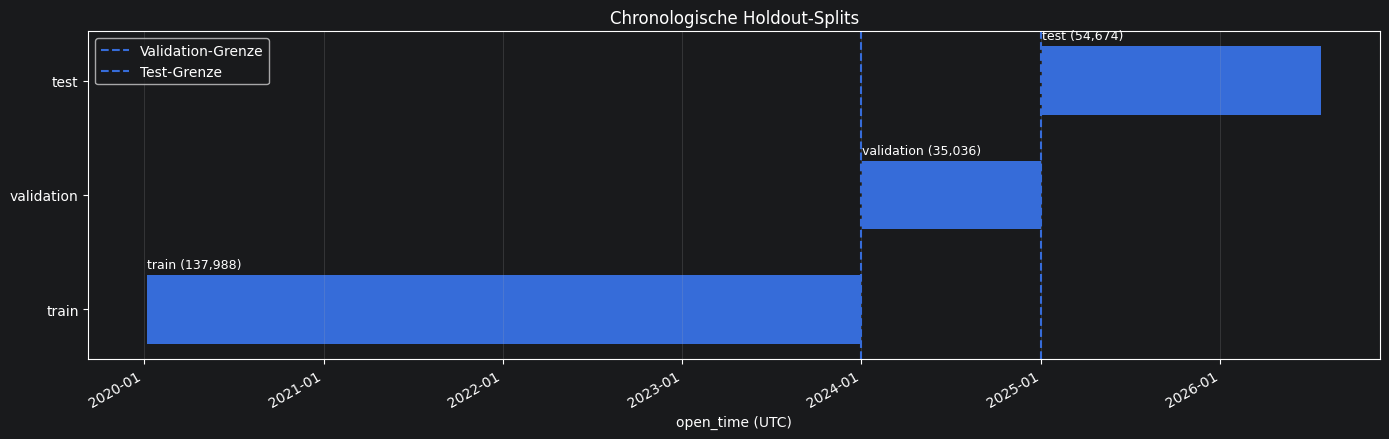

In [8]:
holdout_timeline = []
for name, frame in holdout_metadata.items():
    holdout_timeline.append(
        {
            "partition": name,
            "start": frame["open_time"].min(),
            "end": frame["open_time"].max(),
            "rows": len(frame),
        }
    )
holdout_timeline = pd.DataFrame(holdout_timeline)

figure, axis = plt.subplots(figsize=(14, 4.5))
for index, row in holdout_timeline.iterrows():
    start_number = mdates.date2num(row["start"])
    end_number = mdates.date2num(row["end"])
    axis.broken_barh(
        [(start_number, end_number - start_number)],
        (index - 0.3, 0.6),
    )
    axis.text(
        start_number,
        index + 0.36,
        f"{row['partition']} ({row['rows']:,})",
        fontsize=9,
    )

axis.axvline(
    mdates.date2num(boundaries.validation_start),
    linestyle="--",
    label="Validation-Grenze",
)
axis.axvline(
    mdates.date2num(boundaries.test_start),
    linestyle="--",
    label="Test-Grenze",
)
axis.set_yticks(range(len(holdout_timeline)))
axis.set_yticklabels(holdout_timeline["partition"])
axis.xaxis_date()
axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axis.set_title("Chronologische Holdout-Splits")
axis.set_xlabel("open_time (UTC)")
axis.grid(True, axis="x", alpha=0.25)
axis.legend()
figure.autofmt_xdate()
figure.tight_layout()
display(figure)
plt.close(figure)

## 9. Purging an den Holdout-Grenzen

Purging entfernt Trainings- beziehungsweise Validationzeilen, deren
Targetfenster die nächste Splitgrenze erreicht oder überschreitet.

In [9]:
purging_checks = pd.DataFrame(
    [
        {
            "transition": "train -> validation",
            "last_open_time_left": holdout_metadata["train"][
                "open_time"
            ].max(),
            "last_target_end_left": holdout_metadata["train"][
                target_end_time_column
            ].max(),
            "boundary": boundaries.validation_start,
            "first_open_time_right": holdout_metadata["validation"][
                "open_time"
            ].min(),
            "target_before_boundary": (
                holdout_metadata["train"][target_end_time_column].max()
                < boundaries.validation_start
            ),
        },
        {
            "transition": "validation -> test",
            "last_open_time_left": holdout_metadata["validation"][
                "open_time"
            ].max(),
            "last_target_end_left": holdout_metadata["validation"][
                target_end_time_column
            ].max(),
            "boundary": boundaries.test_start,
            "first_open_time_right": holdout_metadata["test"][
                "open_time"
            ].min(),
            "target_before_boundary": (
                holdout_metadata["validation"][
                    target_end_time_column
                ].max()
                < boundaries.test_start
            ),
        },
    ]
)
display(purging_checks)
assert purging_checks["target_before_boundary"].all()

,transition,last_open_time_left,last_target_end_left,boundary,first_open_time_right,target_before_boundary
0,train -> validation,2023-12-31 22:45:00+00:00,2023-12-31 23:45:00+00:00,2024-01-01 00:00:00+00:00,2024-01-02 00:00:00+00:00,True
1,validation -> test,2024-12-31 22:45:00+00:00,2024-12-31 23:45:00+00:00,2025-01-01 00:00:00+00:00,2025-01-02 00:00:00+00:00,True


## 10. Embargo nach den Holdout-Grenzen

Nach Validation- und Testgrenze werden standardmäßig 96 Kerzen
ausgeschlossen. Bei 15-Minuten-Daten entspricht das 24 Stunden.

In [10]:
embargo_checks = pd.DataFrame(
    [
        {
            "partition": "validation",
            "boundary": boundaries.validation_start,
            "expected_first_open_time": (
                boundaries.validation_start
                + boundaries.embargo_duration
            ),
            "actual_first_open_time": holdout_metadata["validation"][
                "open_time"
            ].min(),
        },
        {
            "partition": "test",
            "boundary": boundaries.test_start,
            "expected_first_open_time": (
                boundaries.test_start
                + boundaries.embargo_duration
            ),
            "actual_first_open_time": holdout_metadata["test"][
                "open_time"
            ].min(),
        },
    ]
)
embargo_checks["actual_embargo"] = (
    embargo_checks["actual_first_open_time"]
    - embargo_checks["boundary"]
)
embargo_checks["passed"] = (
    embargo_checks["actual_first_open_time"]
    >= embargo_checks["expected_first_open_time"]
)
display(embargo_checks)
assert embargo_checks["passed"].all()

,partition,boundary,expected_first_open_time,actual_first_open_time,actual_embargo,passed
0,validation,2024-01-01 00:00:00+00:00,2024-01-02 00:00:00+00:00,2024-01-02 00:00:00+00:00,1 days,True
1,test,2025-01-01 00:00:00+00:00,2025-01-02 00:00:00+00:00,2025-01-02 00:00:00+00:00,1 days,True


## 11. Keine Schlüsselüberschneidung zwischen Holdout-Splits

In [11]:
def key_index(frame: pd.DataFrame) -> pd.MultiIndex:
    return pd.MultiIndex.from_frame(
        frame[["symbol", "interval", "open_time"]]
    )


holdout_overlap_rows = []
for left_name, right_name in (
    ("train", "validation"),
    ("train", "test"),
    ("validation", "test"),
):
    overlap = key_index(
        holdout_metadata[left_name]
    ).intersection(
        key_index(holdout_metadata[right_name])
    )
    holdout_overlap_rows.append(
        {
            "left": left_name,
            "right": right_name,
            "overlapping_keys": len(overlap),
            "passed": len(overlap) == 0,
        }
    )

holdout_overlap = pd.DataFrame(holdout_overlap_rows)
display(holdout_overlap)
assert holdout_overlap["passed"].all()

,left,right,overlapping_keys,passed
0,train,validation,0,True
1,train,test,0,True
2,validation,test,0,True


## 12. Exakte Holdout-Auswahl aus dem Quelldatensatz

Die gespeicherten Dateien müssen exakt den definierten Zeitmasken des
Quelldatensatzes entsprechen. Es werden nur Metadaten verglichen.

In [12]:
holdout_definitions = create_holdout_definitions(
    split_root,
    boundaries,
    purge_overlapping=bool(
        SETTINGS.split.purge_overlapping_targets
    ),
)


def definition_mask(
    frame: pd.DataFrame,
    definition,
) -> np.ndarray:
    mask = np.array(
        frame["open_time"] >= definition.open_start,
        dtype=bool,
        copy=True,
    )
    if definition.open_end_exclusive is not None:
        mask = np.logical_and(
            mask,
            np.array(
                frame["open_time"]
                < definition.open_end_exclusive,
                dtype=bool,
                copy=True,
            ),
        )
    if definition.target_end_limit_exclusive is not None:
        mask = np.logical_and(
            mask,
            np.array(
                frame[target_end_time_column]
                < definition.target_end_limit_exclusive,
                dtype=bool,
                copy=True,
            ),
        )
    return mask


exact_selection_rows = []
for definition in holdout_definitions:
    expected = source_metadata.loc[
        definition_mask(source_metadata, definition),
        metadata_columns,
    ].reset_index(drop=True)
    actual = holdout_metadata[definition.role][
        metadata_columns
    ].reset_index(drop=True)

    try:
        pd.testing.assert_frame_equal(
            expected,
            actual,
            check_exact=True,
            check_dtype=True,
        )
        passed = True
        message = ""
    except AssertionError as error:
        passed = False
        message = str(error).splitlines()[0]

    exact_selection_rows.append(
        {
            "partition": definition.role,
            "expected_rows": len(expected),
            "actual_rows": len(actual),
            "passed": passed,
            "message": message,
        }
    )

exact_holdout_selection = pd.DataFrame(exact_selection_rows)
display(exact_holdout_selection)
assert exact_holdout_selection["passed"].all()

,partition,expected_rows,actual_rows,passed,message
0,train,137988,137988,True,
1,validation,35036,35036,True,
2,test,54674,54674,True,


## 13. Nicht zugewiesene Zeilen und Sicherheitsabstände

In [13]:
selected_key_union = key_index(holdout_metadata["train"])
selected_key_union = selected_key_union.union(
    key_index(holdout_metadata["validation"])
)
selected_key_union = selected_key_union.union(
    key_index(holdout_metadata["test"])
)

source_keys = key_index(source_metadata)
assigned_mask = source_keys.isin(selected_key_union)
unassigned = source_metadata.loc[
    ~assigned_mask
].copy().reset_index(drop=True)

if not unassigned.empty:
    unassigned["date"] = unassigned["open_time"].dt.date
    unassigned_daily = (
        unassigned.groupby("date", observed=True)
        .size()
        .rename("rows")
        .reset_index()
    )
    display(unassigned_daily.head(20))
    print(f"Nicht zugewiesene Quellzeilen: {len(unassigned):,}")
else:
    unassigned_daily = pd.DataFrame(columns=["date", "rows"])
    print("Alle Quellzeilen wurden einem Holdout-Split zugeordnet.")

,date,rows
0,2023-12-31,4
1,2024-01-01,96
2,2024-12-31,4
3,2025-01-01,96


Nicht zugewiesene Quellzeilen: 200


## 14. Walk-Forward-Folddefinitionen

In [14]:
if strategy == "expanding_window":
    generated_fold_definitions = create_expanding_window_folds(
        split_root,
        boundaries,
        folds=fold_count,
        validation_window_days=validation_window_days,
        step_size_days=step_size_days,
        purge_overlapping=bool(
            SETTINGS.split.purge_overlapping_targets
        ),
    )
elif strategy == "rolling_window":
    generated_fold_definitions = create_rolling_window_folds(
        split_root,
        boundaries,
        folds=fold_count,
        validation_window_days=validation_window_days,
        rolling_train_window_days=rolling_train_window_days,
        step_size_days=step_size_days,
        purge_overlapping=bool(
            SETTINGS.split.purge_overlapping_targets
        ),
    )
else:
    raise ValueError(f"Unbekannte Splitstrategie: {strategy}")

fold_definition_table = pd.DataFrame(
    [definition.to_dict() for definition in generated_fold_definitions]
)
display(fold_definition_table)

,name,kind,role,output_path,candidate_start,open_start,open_end_exclusive,target_end_limit_exclusive,fold_index,strategy
0,fold_01_train,cross_validation,train,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,2020-01-01T00:00:00+00:00,2020-01-01T00:00:00+00:00,2023-06-05T00:00:00+00:00,2023-06-05T00:00:00+00:00,1,expanding_window
1,fold_01_validation,cross_validation,validation,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,2023-06-05T00:00:00+00:00,2023-06-06T00:00:00+00:00,2023-09-03T00:00:00+00:00,2023-09-03T00:00:00+00:00,1,expanding_window
2,fold_02_train,cross_validation,train,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,2020-01-01T00:00:00+00:00,2020-01-01T00:00:00+00:00,2023-07-05T00:00:00+00:00,2023-07-05T00:00:00+00:00,2,expanding_window
3,fold_02_validation,cross_validation,validation,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,2023-07-05T00:00:00+00:00,2023-07-06T00:00:00+00:00,2023-10-03T00:00:00+00:00,2023-10-03T00:00:00+00:00,2,expanding_window
4,fold_03_train,cross_validation,train,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,2020-01-01T00:00:00+00:00,2020-01-01T00:00:00+00:00,2023-08-04T00:00:00+00:00,2023-08-04T00:00:00+00:00,3,expanding_window
5,fold_03_validation,cross_validation,validation,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,2023-08-04T00:00:00+00:00,2023-08-05T00:00:00+00:00,2023-11-02T00:00:00+00:00,2023-11-02T00:00:00+00:00,3,expanding_window
6,fold_04_train,cross_validation,train,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,2020-01-01T00:00:00+00:00,2020-01-01T00:00:00+00:00,2023-09-03T00:00:00+00:00,2023-09-03T00:00:00+00:00,4,expanding_window
7,fold_04_validation,cross_validation,validation,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,2023-09-03T00:00:00+00:00,2023-09-04T00:00:00+00:00,2023-12-02T00:00:00+00:00,2023-12-02T00:00:00+00:00,4,expanding_window
8,fold_05_train,cross_validation,train,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,2020-01-01T00:00:00+00:00,2020-01-01T00:00:00+00:00,2023-10-03T00:00:00+00:00,2023-10-03T00:00:00+00:00,5,expanding_window
9,fold_05_validation,cross_validation,validation,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,2023-10-03T00:00:00+00:00,2023-10-04T00:00:00+00:00,2024-01-01T00:00:00+00:00,2024-01-01T00:00:00+00:00,5,expanding_window


## 15. Fold-Übersicht

In [15]:
fold_rows = []
for fold_name, partitions in fold_metadata.items():
    for role, frame in partitions.items():
        fold_rows.append(
            {
                "fold": fold_name,
                "role": role,
                "rows": len(frame),
                "first_open_time": frame["open_time"].min(),
                "last_open_time": frame["open_time"].max(),
                "last_target_end_time": frame[
                    target_end_time_column
                ].max(),
                "target_missing": int(
                    frame[target_column].isna().sum()
                ),
                "chronological": (
                    frame["open_time"].is_monotonic_increasing
                ),
            }
        )

fold_overview = pd.DataFrame(fold_rows)
display(fold_overview)

,fold,role,rows,first_open_time,last_open_time,last_target_end_time,target_missing,chronological
0,fold_01,train,117828,2020-01-08 00:00:00+00:00,2023-06-04 22:45:00+00:00,2023-06-04 23:45:00+00:00,0,True
1,fold_01,validation,8540,2023-06-06 00:00:00+00:00,2023-09-02 22:45:00+00:00,2023-09-02 23:45:00+00:00,0,True
2,fold_02,train,120708,2020-01-08 00:00:00+00:00,2023-07-04 22:45:00+00:00,2023-07-04 23:45:00+00:00,0,True
3,fold_02,validation,8540,2023-07-06 00:00:00+00:00,2023-10-02 22:45:00+00:00,2023-10-02 23:45:00+00:00,0,True
4,fold_03,train,123588,2020-01-08 00:00:00+00:00,2023-08-03 22:45:00+00:00,2023-08-03 23:45:00+00:00,0,True
5,fold_03,validation,8540,2023-08-05 00:00:00+00:00,2023-11-01 22:45:00+00:00,2023-11-01 23:45:00+00:00,0,True
6,fold_04,train,126468,2020-01-08 00:00:00+00:00,2023-09-02 22:45:00+00:00,2023-09-02 23:45:00+00:00,0,True
7,fold_04,validation,8540,2023-09-04 00:00:00+00:00,2023-12-01 22:45:00+00:00,2023-12-01 23:45:00+00:00,0,True
8,fold_05,train,129348,2020-01-08 00:00:00+00:00,2023-10-02 22:45:00+00:00,2023-10-02 23:45:00+00:00,0,True
9,fold_05,validation,8540,2023-10-04 00:00:00+00:00,2023-12-31 22:45:00+00:00,2023-12-31 23:45:00+00:00,0,True


## 16. Visualisierung der Walk-Forward-Folds

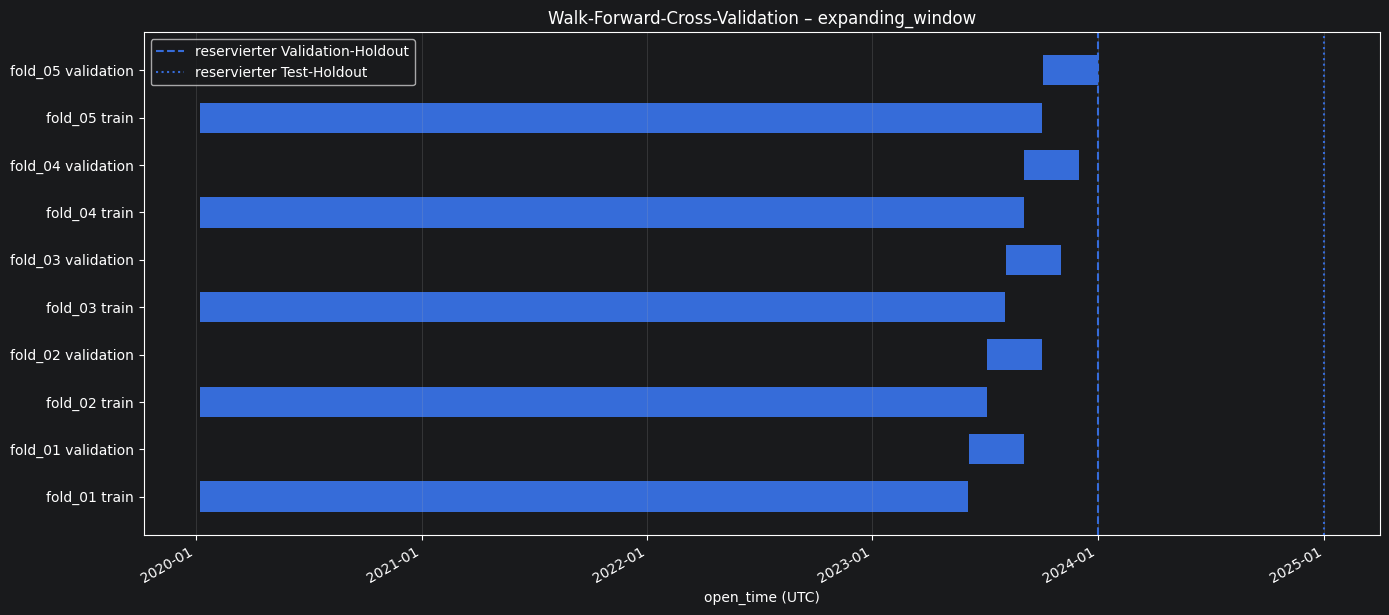

In [16]:
figure, axis = plt.subplots(
    figsize=(14, max(5, len(fold_directories) * 1.25))
)

y_position = 0
y_ticks = []
y_labels = []

for fold_name in sorted(fold_metadata):
    for role in ("train", "validation"):
        frame = fold_metadata[fold_name][role]
        start = frame["open_time"].min()
        end = frame["open_time"].max()
        start_number = mdates.date2num(start)
        end_number = mdates.date2num(end)

        axis.broken_barh(
            [(start_number, end_number - start_number)],
            (y_position - 0.32, 0.64),
        )
        y_ticks.append(y_position)
        y_labels.append(f"{fold_name} {role}")
        y_position += 1

axis.axvline(
    mdates.date2num(boundaries.validation_start),
    linestyle="--",
    label="reservierter Validation-Holdout",
)
axis.axvline(
    mdates.date2num(boundaries.test_start),
    linestyle=":",
    label="reservierter Test-Holdout",
)
axis.set_yticks(y_ticks)
axis.set_yticklabels(y_labels)
axis.xaxis_date()
axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axis.set_title(
    f"Walk-Forward-Cross-Validation – {strategy}"
)
axis.set_xlabel("open_time (UTC)")
axis.grid(True, axis="x", alpha=0.25)
axis.legend()
figure.autofmt_xdate()
figure.tight_layout()
display(figure)
plt.close(figure)

## 17. Expanding- beziehungsweise Rolling-Window-Eigenschaft

In [17]:
train_window_rows = []
for fold_name in sorted(fold_metadata):
    train_frame = fold_metadata[fold_name]["train"]
    train_window_rows.append(
        {
            "fold": fold_name,
            "rows": len(train_frame),
            "start": train_frame["open_time"].min(),
            "end": train_frame["open_time"].max(),
            "duration_days": (
                train_frame["open_time"].max()
                - train_frame["open_time"].min()
            ).total_seconds() / 86_400,
        }
    )

train_windows = pd.DataFrame(train_window_rows)
train_windows["row_change"] = train_windows["rows"].diff()
train_windows["start_change"] = train_windows["start"].diff()
display(train_windows)

if strategy == "expanding_window":
    strategy_passed = (
        train_windows["rows"].is_monotonic_increasing
        and train_windows["start"].nunique() == 1
    )
else:
    strategy_passed = (
        train_windows["start"].is_monotonic_increasing
        and train_windows["duration_days"].max()
        <= rolling_train_window_days + 1
    )

print(f"Strategieprüfung bestanden: {strategy_passed}")
assert strategy_passed

,fold,rows,start,end,duration_days,row_change,start_change
0,fold_01,117828,2020-01-08 00:00:00+00:00,2023-06-04 22:45:00+00:00,"1,243.947917",NaN,NaT
1,fold_02,120708,2020-01-08 00:00:00+00:00,2023-07-04 22:45:00+00:00,"1,273.947917","2,880.000000",0 days
2,fold_03,123588,2020-01-08 00:00:00+00:00,2023-08-03 22:45:00+00:00,"1,303.947917","2,880.000000",0 days
3,fold_04,126468,2020-01-08 00:00:00+00:00,2023-09-02 22:45:00+00:00,"1,333.947917","2,880.000000",0 days
4,fold_05,129348,2020-01-08 00:00:00+00:00,2023-10-02 22:45:00+00:00,"1,363.947917","2,880.000000",0 days


Strategieprüfung bestanden: True


## 18. Purging und Embargo je Fold

In [18]:
fold_safety_rows = []
definitions_by_name = {
    definition.name: definition
    for definition in generated_fold_definitions
}

for fold_name in sorted(fold_metadata):
    train_frame = fold_metadata[fold_name]["train"]
    validation_frame = fold_metadata[fold_name]["validation"]
    train_definition = definitions_by_name[f"{fold_name}_train"]
    validation_definition = definitions_by_name[
        f"{fold_name}_validation"
    ]

    fold_safety_rows.append(
        {
            "fold": fold_name,
            "train_last_target_end": train_frame[
                target_end_time_column
            ].max(),
            "validation_boundary": (
                train_definition.open_end_exclusive
            ),
            "train_purging_passed": (
                train_frame[target_end_time_column].max()
                < train_definition.open_end_exclusive
            ),
            "expected_validation_start": (
                validation_definition.open_start
            ),
            "actual_validation_start": (
                validation_frame["open_time"].min()
            ),
            "embargo_passed": (
                validation_frame["open_time"].min()
                >= validation_definition.open_start
            ),
            "validation_last_target_end": (
                validation_frame[target_end_time_column].max()
            ),
            "validation_end_exclusive": (
                validation_definition.open_end_exclusive
            ),
            "validation_purging_passed": (
                validation_frame[target_end_time_column].max()
                < validation_definition.open_end_exclusive
            ),
        }
    )

fold_safety = pd.DataFrame(fold_safety_rows)
display(fold_safety)
assert fold_safety[
    [
        "train_purging_passed",
        "embargo_passed",
        "validation_purging_passed",
    ]
].all().all()

,fold,train_last_target_end,validation_boundary,train_purging_passed,expected_validation_start,actual_validation_start,embargo_passed,validation_last_target_end,validation_end_exclusive,validation_purging_passed
0,fold_01,2023-06-04 23:45:00+00:00,2023-06-05 00:00:00+00:00,True,2023-06-06 00:00:00+00:00,2023-06-06 00:00:00+00:00,True,2023-09-02 23:45:00+00:00,2023-09-03 00:00:00+00:00,True
1,fold_02,2023-07-04 23:45:00+00:00,2023-07-05 00:00:00+00:00,True,2023-07-06 00:00:00+00:00,2023-07-06 00:00:00+00:00,True,2023-10-02 23:45:00+00:00,2023-10-03 00:00:00+00:00,True
2,fold_03,2023-08-03 23:45:00+00:00,2023-08-04 00:00:00+00:00,True,2023-08-05 00:00:00+00:00,2023-08-05 00:00:00+00:00,True,2023-11-01 23:45:00+00:00,2023-11-02 00:00:00+00:00,True
3,fold_04,2023-09-02 23:45:00+00:00,2023-09-03 00:00:00+00:00,True,2023-09-04 00:00:00+00:00,2023-09-04 00:00:00+00:00,True,2023-12-01 23:45:00+00:00,2023-12-02 00:00:00+00:00,True
4,fold_05,2023-10-02 23:45:00+00:00,2023-10-03 00:00:00+00:00,True,2023-10-04 00:00:00+00:00,2023-10-04 00:00:00+00:00,True,2023-12-31 23:45:00+00:00,2024-01-01 00:00:00+00:00,True


## 19. Keine Schlüsselüberschneidung innerhalb der Folds

In [19]:
fold_overlap_rows = []
for fold_name, partitions in fold_metadata.items():
    overlap = key_index(partitions["train"]).intersection(
        key_index(partitions["validation"])
    )
    fold_overlap_rows.append(
        {
            "fold": fold_name,
            "overlapping_keys": len(overlap),
            "passed": len(overlap) == 0,
        }
    )

fold_overlap = pd.DataFrame(fold_overlap_rows)
display(fold_overlap)
assert fold_overlap["passed"].all()

,fold,overlapping_keys,passed
0,fold_01,0,True
1,fold_02,0,True
2,fold_03,0,True
3,fold_04,0,True
4,fold_05,0,True


## 20. Cross-Validation bleibt vor dem reservierten Holdout

Weder der Validation-Holdout ab 2024 noch der Test-Holdout ab 2025 darf
in den Cross-Validation-Folds verwendet werden.

In [20]:
cv_boundary_rows = []
for fold_name, partitions in fold_metadata.items():
    for role, frame in partitions.items():
        maximum_open_time = frame["open_time"].max()
        cv_boundary_rows.append(
            {
                "fold": fold_name,
                "role": role,
                "maximum_open_time": maximum_open_time,
                "before_validation_holdout": (
                    maximum_open_time < boundaries.validation_start
                ),
                "before_test_holdout": (
                    maximum_open_time < boundaries.test_start
                ),
            }
        )

cv_boundary_check = pd.DataFrame(cv_boundary_rows)
display(cv_boundary_check)
assert cv_boundary_check[
    ["before_validation_holdout", "before_test_holdout"]
].all().all()

,fold,role,maximum_open_time,before_validation_holdout,before_test_holdout
0,fold_01,train,2023-06-04 22:45:00+00:00,True,True
1,fold_01,validation,2023-09-02 22:45:00+00:00,True,True
2,fold_02,train,2023-07-04 22:45:00+00:00,True,True
3,fold_02,validation,2023-10-02 22:45:00+00:00,True,True
4,fold_03,train,2023-08-03 22:45:00+00:00,True,True
5,fold_03,validation,2023-11-01 22:45:00+00:00,True,True
6,fold_04,train,2023-09-02 22:45:00+00:00,True,True
7,fold_04,validation,2023-12-01 22:45:00+00:00,True,True
8,fold_05,train,2023-10-02 22:45:00+00:00,True,True
9,fold_05,validation,2023-12-31 22:45:00+00:00,True,True


## 21. Exakte Fold-Auswahl aus dem Quelldatensatz

In [21]:
exact_fold_rows = []
for definition in generated_fold_definitions:
    fold_name = f"fold_{int(definition.fold_index):02d}"
    actual = fold_metadata[fold_name][definition.role][
        metadata_columns
    ].reset_index(drop=True)
    expected = source_metadata.loc[
        definition_mask(source_metadata, definition),
        metadata_columns,
    ].reset_index(drop=True)

    try:
        pd.testing.assert_frame_equal(
            expected,
            actual,
            check_exact=True,
            check_dtype=True,
        )
        passed = True
        message = ""
    except AssertionError as error:
        passed = False
        message = str(error).splitlines()[0]

    exact_fold_rows.append(
        {
            "split": definition.name,
            "expected_rows": len(expected),
            "actual_rows": len(actual),
            "passed": passed,
            "message": message,
        }
    )

exact_fold_selection = pd.DataFrame(exact_fold_rows)
display(exact_fold_selection)
assert exact_fold_selection["passed"].all()

,split,expected_rows,actual_rows,passed,message
0,fold_01_train,117828,117828,True,
1,fold_01_validation,8540,8540,True,
2,fold_02_train,120708,120708,True,
3,fold_02_validation,8540,8540,True,
4,fold_03_train,123588,123588,True,
5,fold_03_validation,8540,8540,True,
6,fold_04_train,126468,126468,True,
7,fold_04_validation,8540,8540,True,
8,fold_05_train,129348,129348,True,
9,fold_05_validation,8540,8540,True,


## 22. Schemaidentität aller Ausgabedateien

In [22]:
source_schema = pq.ParquetFile(
    source_dataset_path
).schema_arrow

schema_rows = []
for record in parquet_rows[1:]:
    path = Path(record["path"])
    current_schema = pq.ParquetFile(path).schema_arrow
    schema_rows.append(
        {
            "role": record["role"],
            "column_count": len(current_schema.names),
            "same_schema": current_schema.equals(
                source_schema,
                check_metadata=False,
            ),
            "same_column_order": (
                current_schema.names == source_schema.names
            ),
        }
    )

schema_check = pd.DataFrame(schema_rows)
display(schema_check)
assert schema_check[
    ["same_schema", "same_column_order"]
].all().all()

,role,column_count,same_schema,same_column_order
0,holdout_train,340,True,True
1,holdout_validation,340,True,True
2,holdout_test,340,True,True
3,fold_01_train,340,True,True
4,fold_01_validation,340,True,True
5,fold_02_train,340,True,True
6,fold_02_validation,340,True,True
7,fold_03_train,340,True,True
8,fold_03_validation,340,True,True
9,fold_04_train,340,True,True


## 23. Exakte Target-Endzeit je Split

In [23]:
interval_delta = boundaries.interval_duration
expected_target_delta = horizon * interval_delta

target_alignment_rows = []
frames_to_check = {
    "source": source_metadata,
    **{
        f"holdout_{name}": frame
        for name, frame in holdout_metadata.items()
    },
}
for fold_name, partitions in fold_metadata.items():
    for role, frame in partitions.items():
        frames_to_check[f"{fold_name}_{role}"] = frame

for name, frame in frames_to_check.items():
    expected_end_time = frame["open_time"] + expected_target_delta
    mismatch_count = int(
        (
            frame[target_end_time_column]
            != expected_end_time
        ).sum()
    )
    target_alignment_rows.append(
        {
            "partition": name,
            "rows": len(frame),
            "target_end_mismatches": mismatch_count,
            "passed": mismatch_count == 0,
        }
    )

target_alignment = pd.DataFrame(target_alignment_rows)
display(target_alignment)
assert target_alignment["passed"].all()

,partition,rows,target_end_mismatches,passed
0,source,227898,0,True
1,holdout_train,137988,0,True
2,holdout_validation,35036,0,True
3,holdout_test,54674,0,True
4,fold_01_train,117828,0,True
5,fold_01_validation,8540,0,True
6,fold_02_train,120708,0,True
7,fold_02_validation,8540,0,True
8,fold_03_train,123588,0,True
9,fold_03_validation,8540,0,True


## 24. Klassen- beziehungsweise Targetverteilung im Holdout

,partition,target_value,count,ratio
0,train,0,84319,0.611060
1,train,1,53669,0.388940
2,validation,0,21328,0.608745
3,validation,1,13708,0.391255


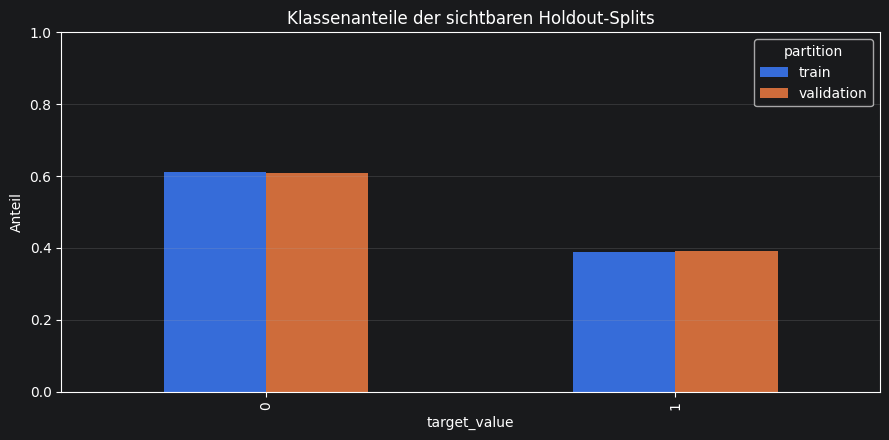

In [24]:
def target_distribution(
    frame: pd.DataFrame,
    partition: str,
) -> pd.DataFrame:
    if task in {
        "binary_classification",
        "multiclass_classification",
    }:
        counts = (
            frame[target_column]
            .value_counts(dropna=False)
            .sort_index()
        )
        result = counts.rename("count").reset_index()
        result = result.rename(
            columns={target_column: "target_value", "index": "target_value"}
        )
        result["ratio"] = result["count"] / len(frame)
        result["partition"] = partition
        return result[
            ["partition", "target_value", "count", "ratio"]
        ]

    values = pd.to_numeric(frame[target_column], errors="coerce")
    return pd.DataFrame(
        [
            {
                "partition": partition,
                "count": int(values.notna().sum()),
                "mean": float(values.mean()),
                "std": float(values.std()),
                "median": float(values.median()),
                "minimum": float(values.min()),
                "maximum": float(values.max()),
            }
        ]
    )


visible_holdout_partitions = ["train", "validation"]
if SHOW_TEST_TARGET_DISTRIBUTION:
    visible_holdout_partitions.append("test")

holdout_distribution = pd.concat(
    [
        target_distribution(
            holdout_metadata[name],
            name,
        )
        for name in visible_holdout_partitions
    ],
    ignore_index=True,
)
display(holdout_distribution)

if task in {
    "binary_classification",
    "multiclass_classification",
}:
    pivot = holdout_distribution.pivot(
        index="target_value",
        columns="partition",
        values="ratio",
    ).fillna(0)
    figure, axis = plt.subplots(figsize=(9, 4.5))
    pivot.plot(kind="bar", ax=axis)
    axis.set_title("Klassenanteile der sichtbaren Holdout-Splits")
    axis.set_ylabel("Anteil")
    axis.set_ylim(0, 1)
    axis.grid(True, axis="y", alpha=0.25)
    figure.tight_layout()
    display(figure)
    plt.close(figure)

## 25. Klassen- beziehungsweise Targetstabilität der Folds

,fold,role,target_value,ratio
0,fold_01,train,0,0.599959
1,fold_01,train,1,0.400041
2,fold_01,validation,0,0.707611
3,fold_01,validation,1,0.292389
4,fold_02,train,0,0.600938
5,fold_02,train,1,0.399062
6,fold_02,validation,0,0.731265
7,fold_02,validation,1,0.268735
8,fold_03,train,0,0.603821
9,fold_03,train,1,0.396179


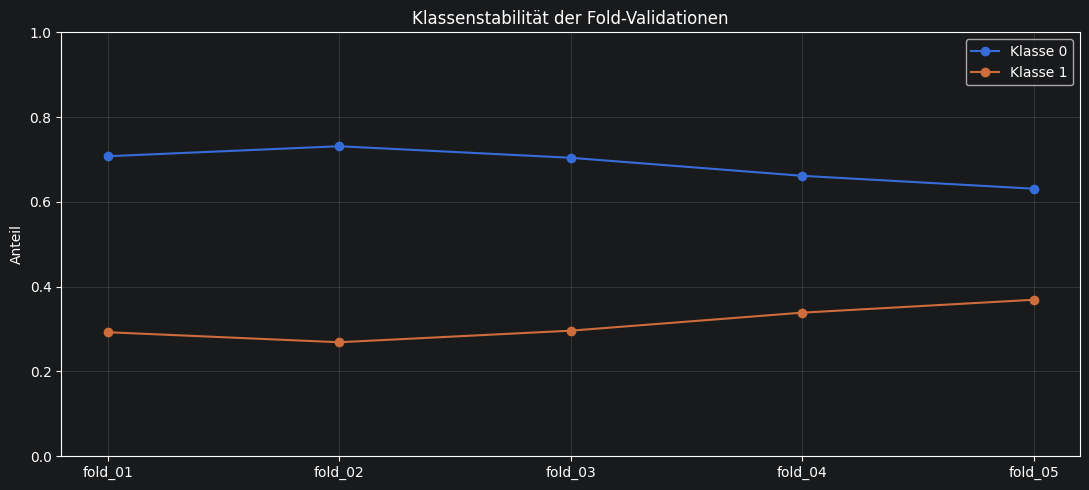

In [25]:
fold_distribution_rows = []
for fold_name, partitions in fold_metadata.items():
    for role, frame in partitions.items():
        if task in {
            "binary_classification",
            "multiclass_classification",
        }:
            counts = (
                frame[target_column]
                .value_counts(normalize=True)
                .sort_index()
            )
            for value, ratio in counts.items():
                fold_distribution_rows.append(
                    {
                        "fold": fold_name,
                        "role": role,
                        "target_value": value,
                        "ratio": float(ratio),
                    }
                )
        else:
            values = pd.to_numeric(
                frame[target_column],
                errors="coerce",
            )
            fold_distribution_rows.append(
                {
                    "fold": fold_name,
                    "role": role,
                    "mean": float(values.mean()),
                    "std": float(values.std()),
                    "median": float(values.median()),
                }
            )

fold_distribution = pd.DataFrame(fold_distribution_rows)
display(fold_distribution)

if task in {
    "binary_classification",
    "multiclass_classification",
}:
    validation_distribution = fold_distribution.loc[
        fold_distribution["role"] == "validation"
    ]
    figure, axis = plt.subplots(figsize=(11, 5))
    for target_value, group in validation_distribution.groupby(
        "target_value", observed=True
    ):
        axis.plot(
            group["fold"],
            group["ratio"],
            marker="o",
            label=f"Klasse {target_value}",
        )
    axis.set_title("Klassenstabilität der Fold-Validationen")
    axis.set_ylabel("Anteil")
    axis.set_ylim(0, 1)
    axis.grid(True, alpha=0.25)
    axis.legend()
    figure.tight_layout()
    display(figure)
    plt.close(figure)

## 26. Produktive Split-Eingabevalidierung

Diese Prüfung lädt ebenfalls nur Schlüssel, Target und Schema. Sie
erkennt unter anderem nichtnumerische Features, doppelte Schlüssel,
ungültige Klassen und Target-Endzeitfehler.

In [26]:
(
    split_input_report,
    validated_source_metadata,
    validated_source_schema,
    validated_feature_columns,
) = validate_split_input(
    source_dataset_path,
    SETTINGS,
    task=task,
    horizon=horizon,
    target_column=target_column,
    target_end_time_column=target_end_time_column,
)

display(pd.DataFrame([split_input_report.to_dict()]))
print(split_input_report.summary)
assert split_input_report.is_valid
assert validated_source_schema.equals(
    source_schema,
    check_metadata=False,
)

,generated_at,dataset_path,row_count,column_count,feature_count,task,horizon,target_column,target_end_time_column,first_open_time,last_open_time,duplicate_key_rows,unsorted,missing_counts,invalid_end_time_rows,non_numeric_feature_columns,target_like_feature_columns,unexpected_target_columns,invalid_target_values,errors,warnings
0,2026-07-27T19:43:45.558943+00:00,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,227898,340,335,binary_classification,4,target_binary_4,target_end_time_4,2020-01-08T00:00:00+00:00,2026-07-25T12:15:00+00:00,0,False,{},0,[],[],[],[],[],[]


Split-Eingabe gültig.


## 27. Bestehende Splitdateien mit dem Produktivmodul prüfen

In [27]:
existing_validation = validate_existing_splits(
    SETTINGS,
    dataset_path=source_dataset_path,
    output_root=split_root,
    task=task,
    horizon=horizon,
    split_name=split_name,
)
display(pd.DataFrame([existing_validation]))
assert existing_validation["is_valid"]

,split_name,task,horizon,source_path,source_exists,output_root,output_exists,parquet_file_count,files,is_valid,errors
0,primary,binary_classification,4,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,True,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,True,13,[{'path': '/home/milan/uni/python/BTC TSP/BTC ...,True,[]


## 28. Splitübersicht des Produktivmoduls

In [28]:
module_overview = split_overview(
    SETTINGS,
    dataset_path=source_dataset_path,
    output_root=split_root,
    task=task,
    horizon=horizon,
    split_name=split_name,
)
display(pd.DataFrame(module_overview["files"]))

,path,rows,size_bytes,sha256
0,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,117828,312101652,56923496adf6cf59b896af8e7a7ee10fe8dde54e41ddf5...
1,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,8540,22563996,de0d9eb106f87ff212b8cdc336c7637da5ef76524a5d02...
2,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,120708,319651974,113feecd4f4f3c900b57ae7bde42519b56b5c5b81c5428...
3,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,8540,22548040,65e3ef68a5dfbfb3028fc0b6a28423b9c307a2aa93aef0...
4,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,123588,327352563,d3ca33a813f5a1a15b6d93742acfeb4044666d2895a343...
5,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,8540,22351882,cac9cabafcfc448caf38f9b35fdf3caaef415684848fb9...
6,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,126468,334940046,6536b652bd03b6ee33f25c6a529b30d6c6dfc5755f1962...
7,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,8540,22319949,0f3d0a720f3f9cd1da8e588ae45a99a762d1399c107148...
8,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,129348,342507881,9c8194f2d1d2d8aa08bec9eac7dc82b0f840d920446b95...
9,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,8540,22375884,5b052ed3ed08dfd34b94713acd53742db252fc4c4ffb60...


## 29. Deterministische Splitdefinitionen

In [29]:
def definition_fingerprint(definitions) -> str:
    payload = json.dumps(
        [definition.to_dict() for definition in definitions],
        sort_keys=True,
        ensure_ascii=False,
    ).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


repeated_holdout_definitions = create_holdout_definitions(
    split_root,
    boundaries,
    purge_overlapping=bool(
        SETTINGS.split.purge_overlapping_targets
    ),
)

if strategy == "expanding_window":
    repeated_fold_definitions = create_expanding_window_folds(
        split_root,
        boundaries,
        folds=fold_count,
        validation_window_days=validation_window_days,
        step_size_days=step_size_days,
        purge_overlapping=bool(
            SETTINGS.split.purge_overlapping_targets
        ),
    )
else:
    repeated_fold_definitions = create_rolling_window_folds(
        split_root,
        boundaries,
        folds=fold_count,
        validation_window_days=validation_window_days,
        rolling_train_window_days=rolling_train_window_days,
        step_size_days=step_size_days,
        purge_overlapping=bool(
            SETTINGS.split.purge_overlapping_targets
        ),
    )

first_fingerprint = definition_fingerprint(
    [*holdout_definitions, *generated_fold_definitions]
)
second_fingerprint = definition_fingerprint(
    [*repeated_holdout_definitions, *repeated_fold_definitions]
)
deterministic_definitions = first_fingerprint == second_fingerprint

display(
    pd.DataFrame(
        [
            {
                "first_fingerprint": first_fingerprint,
                "second_fingerprint": second_fingerprint,
                "passed": deterministic_definitions,
            }
        ]
    )
)
assert deterministic_definitions

,first_fingerprint,second_fingerprint,passed
0,a1d6aaf866c90e8d52d96e554a96e3a919b5e81ae1ff9f...,a1d6aaf866c90e8d52d96e554a96e3a919b5e81ae1ff9f...,True


## 30. Gespeicherte Splitberichte

In [30]:
expected_report_files = (
    "split_summary.json",
    "split_manifest.json",
    "split_validation.json",
    "split_boundaries.csv",
    "fold_definitions.csv",
    "purge_diagnostics.csv",
    "class_balance.csv",
    "config_snapshot.json",
)

if latest_report_dir is None:
    report_file_table = pd.DataFrame(
        columns=["file", "exists", "size_kib"]
    )
    print("Kein Splitreport-Verzeichnis gefunden.")
else:
    report_file_table = pd.DataFrame(
        [
            {
                "file": name,
                "exists": (latest_report_dir / name).exists(),
                "size_kib": (
                    (latest_report_dir / name).stat().st_size / 1024
                    if (latest_report_dir / name).exists()
                    else np.nan
                ),
            }
            for name in expected_report_files
        ]
    )
    display(report_file_table)

,file,exists,size_kib
0,split_summary.json,True,17.386719
1,split_manifest.json,True,43.172852
2,split_validation.json,True,11.961914
3,split_boundaries.csv,True,6.393555
4,fold_definitions.csv,True,2.729492
5,purge_diagnostics.csv,True,1.108398
6,class_balance.csv,True,2.109375
7,config_snapshot.json,True,17.788086


## 31. Purging- und Embargo-Diagnostik aus dem Bericht

,split_name,kind,role,fold_index,candidate_rows,embargo_removed_rows,purge_removed_rows,selected_rows,selection_ratio
0,holdout_train,holdout,train,NaN,137992,0,4,137988,0.999971
1,holdout_validation,holdout,validation,NaN,35136,96,4,35036,0.997154
2,holdout_test,holdout,test,NaN,54770,96,0,54674,0.998247
3,fold_01_train,cross_validation,train,1.000000,117832,0,4,117828,0.999966
4,fold_01_validation,cross_validation,validation,1.000000,8640,96,4,8540,0.988426
5,fold_02_train,cross_validation,train,2.000000,120712,0,4,120708,0.999967
6,fold_02_validation,cross_validation,validation,2.000000,8640,96,4,8540,0.988426
7,fold_03_train,cross_validation,train,3.000000,123592,0,4,123588,0.999968
8,fold_03_validation,cross_validation,validation,3.000000,8640,96,4,8540,0.988426
9,fold_04_train,cross_validation,train,4.000000,126472,0,4,126468,0.999968


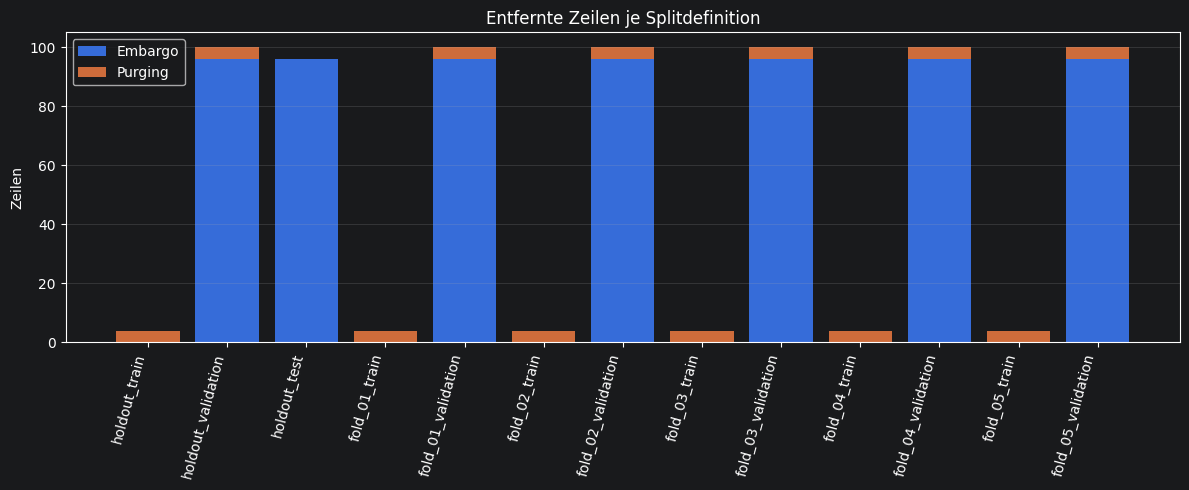

In [31]:
purge_report_path = (
    latest_report_dir / "purge_diagnostics.csv"
    if latest_report_dir is not None
    else None
)

if purge_report_path is not None and purge_report_path.exists():
    purge_diagnostics = pd.read_csv(purge_report_path)
    display(purge_diagnostics)

    figure, axis = plt.subplots(figsize=(12, 5))
    positions = np.arange(len(purge_diagnostics))
    axis.bar(
        positions,
        purge_diagnostics["embargo_removed_rows"],
        label="Embargo",
    )
    axis.bar(
        positions,
        purge_diagnostics["purge_removed_rows"],
        bottom=purge_diagnostics["embargo_removed_rows"],
        label="Purging",
    )
    axis.set_xticks(positions)
    axis.set_xticklabels(
        purge_diagnostics["split_name"],
        rotation=75,
        ha="right",
    )
    axis.set_title("Entfernte Zeilen je Splitdefinition")
    axis.set_ylabel("Zeilen")
    axis.grid(True, axis="y", alpha=0.25)
    axis.legend()
    figure.tight_layout()
    display(figure)
    plt.close(figure)
else:
    purge_diagnostics = pd.DataFrame()
    print("purge_diagnostics.csv ist nicht verfügbar.")

## 32. Validierungsmanifest des Splitters

In [32]:
split_validation_path = (
    latest_report_dir / "split_validation.json"
    if latest_report_dir is not None
    else None
)

if (
    split_validation_path is not None
    and split_validation_path.exists()
):
    split_validation_payload = json.loads(
        split_validation_path.read_text(encoding="utf-8")
    )
    validation_summary = pd.DataFrame(
        [
            {
                "schema_equivalence_passed": (
                    split_validation_payload.get(
                        "schema_equivalence_passed"
                    )
                ),
                "test_source_equivalence_passed": (
                    split_validation_payload.get(
                        "test_source_equivalence_passed"
                    )
                ),
                "deterministic_definitions_passed": (
                    split_validation_payload.get(
                        "deterministic_definitions_passed"
                    )
                ),
                "cv_uses_validation_holdout": (
                    split_validation_payload.get(
                        "cross_validation_uses_validation_holdout"
                    )
                ),
                "cv_uses_test_holdout": (
                    split_validation_payload.get(
                        "cross_validation_uses_test_holdout"
                    )
                ),
                "errors": len(
                    split_validation_payload.get("errors", [])
                ),
                "warnings": len(
                    split_validation_payload.get("warnings", [])
                ),
            }
        ]
    )
    display(validation_summary)
else:
    split_validation_payload = None
    print("split_validation.json ist nicht verfügbar.")

,schema_equivalence_passed,test_source_equivalence_passed,deterministic_definitions_passed,cv_uses_validation_holdout,cv_uses_test_holdout,errors,warnings
0,True,True,True,False,False,0,0


## 33. Abschließendes Freigabegate

In [33]:
release_checks = pd.DataFrame(
    [
        {
            "check": "Split-Eingabe gültig",
            "passed": split_input_report.is_valid,
        },
        {
            "check": "Bestehende Dateien gültig",
            "passed": existing_validation["is_valid"],
        },
        {
            "check": "Holdout chronologisch",
            "passed": holdout_overview["chronological"].all(),
        },
        {
            "check": "Keine Holdout-Duplikate",
            "passed": (
                holdout_overview["duplicate_keys"] == 0
            ).all(),
        },
        {
            "check": "Keine Holdout-Key-Überschneidung",
            "passed": holdout_overlap["passed"].all(),
        },
        {
            "check": "Holdout-Purging korrekt",
            "passed": purging_checks[
                "target_before_boundary"
            ].all(),
        },
        {
            "check": "Holdout-Embargo korrekt",
            "passed": embargo_checks["passed"].all(),
        },
        {
            "check": "Holdout exakt aus Quelle ausgewählt",
            "passed": exact_holdout_selection["passed"].all(),
        },
        {
            "check": "Foldstrategie korrekt",
            "passed": strategy_passed,
        },
        {
            "check": "Fold-Purging und Embargo korrekt",
            "passed": fold_safety[
                [
                    "train_purging_passed",
                    "embargo_passed",
                    "validation_purging_passed",
                ]
            ].all().all(),
        },
        {
            "check": "Keine Fold-Key-Überschneidung",
            "passed": fold_overlap["passed"].all(),
        },
        {
            "check": "CV bleibt vor Validation und Test",
            "passed": cv_boundary_check[
                [
                    "before_validation_holdout",
                    "before_test_holdout",
                ]
            ].all().all(),
        },
        {
            "check": "Folds exakt aus Quelle ausgewählt",
            "passed": exact_fold_selection["passed"].all(),
        },
        {
            "check": "Alle Schemas identisch",
            "passed": schema_check[
                ["same_schema", "same_column_order"]
            ].all().all(),
        },
        {
            "check": "Target-Endzeiten exakt",
            "passed": target_alignment["passed"].all(),
        },
        {
            "check": "Splitdefinitionen deterministisch",
            "passed": deterministic_definitions,
        },
        {
            "check": "Testtarget nicht visualisiert",
            "passed": not SHOW_TEST_TARGET_DISTRIBUTION,
        },
    ]
)

display(release_checks)
assert release_checks["passed"].all(), (
    "Time-Series-Split-Freigabegate fehlgeschlagen."
)

display(
    Markdown(
        f"""
### Ergebnis

Die zeitlichen Splits sind für die Modellierung freigegeben.

- **Task:** `{task}`
- **Horizont:** {horizon} Kerzen
- **Target:** `{target_column}`
- **Holdout-Training:** {len(holdout_metadata['train']):,} Zeilen
- **Holdout-Validation:** {len(holdout_metadata['validation']):,} Zeilen
- **Reservierter Test:** {len(holdout_metadata['test']):,} Zeilen
- **Walk-Forward-Folds:** {len(fold_metadata)}
- **Strategie:** `{strategy}`
- **Embargo:** {boundaries.embargo_candles} Kerzen / {boundaries.embargo_duration}

"""
    )
)

,check,passed
0,Split-Eingabe gültig,True
1,Bestehende Dateien gültig,True
2,Holdout chronologisch,True
3,Keine Holdout-Duplikate,True
4,Keine Holdout-Key-Überschneidung,True
5,Holdout-Purging korrekt,True
6,Holdout-Embargo korrekt,True
7,Holdout exakt aus Quelle ausgewählt,True
8,Foldstrategie korrekt,True
9,Fold-Purging und Embargo korrekt,True



### Ergebnis

Die zeitlichen Splits sind für die Modellierung freigegeben.

- **Task:** `binary_classification`
- **Horizont:** 4 Kerzen
- **Target:** `target_binary_4`
- **Holdout-Training:** 137,988 Zeilen
- **Holdout-Validation:** 35,036 Zeilen
- **Reservierter Test:** 54,674 Zeilen
- **Walk-Forward-Folds:** 5
- **Strategie:** `expanding_window`
- **Embargo:** 96 Kerzen / 1 days 00:00:00

Der nächste Schritt ist `07_baseline_models.ipynb` beziehungsweise
`baseline_models.py`.
